In [5]:
import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [10]:
df = pd.read_csv("../data/raw/books_raw.csv")
df.head()

,title,category,price,rating,availability,description,upc,num_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [11]:
df.shape

(200, 9)

In [16]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         200 non-null    str  
 1   category      200 non-null    str  
 2   price         200 non-null    str  
 3   rating        200 non-null    int64
 4   availability  200 non-null    str  
 5   description   199 non-null    str  
 6   upc           200 non-null    str  
 7   num_reviews   200 non-null    int64
 8   product_url   200 non-null    str  
dtypes: int64(2), str(7)
memory usage: 14.2 KB


In [17]:
max_books = 200

In [27]:
df = pd.read_csv("../data/raw/books_raw.csv")

In [23]:
import os
os.makedirs("../data/raw/processed",exist_ok=True)

In [31]:
df.to_csv("../data/raw/processed/books_cleaned.csv", index=False)

In [33]:
plt.savefig("price_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [34]:
df = pd.read_csv("../data/raw/books_raw.csv")

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [36]:
df = pd.read_csv("../data/raw/books_raw.csv")

In [37]:
df.head()

,title,category,price,rating,availability,description,upc,num_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         200 non-null    str  
 1   category      200 non-null    str  
 2   price         200 non-null    str  
 3   rating        200 non-null    int64
 4   availability  200 non-null    str  
 5   description   199 non-null    str  
 6   upc           200 non-null    str  
 7   num_reviews   200 non-null    int64
 8   product_url   200 non-null    str  
dtypes: int64(2), str(7)
memory usage: 14.2 KB


In [39]:
print("Total records:", len(df))

Total records: 200


In [40]:
df.isnull().sum()

title           0
category        0
price           0
rating          0
availability    0
description     1
upc             0
num_reviews     0
product_url     0
dtype: int64

In [41]:
print("Duplicate UPCs:", df.duplicated(subset="upc").sum())

Duplicate UPCs: 0


In [42]:
df.describe(include="all")

,title,category,price,rating,availability,description,upc,num_reviews,product_url
count,200,200,200,200.000000,200,199,200,200.0,200
unique,200,36,196,NaN,11,199,200,NaN,200
top,It's Only the Himalayas,Default,£33.34,NaN,In stock (16 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,NaN,https://books.toscrape.com/catalogue/its-only-...
freq,1,31,2,NaN,84,1,1,NaN,1
mean,NaN,NaN,NaN,2.865000,NaN,NaN,NaN,0.0,NaN
std,NaN,NaN,NaN,1.451658,NaN,NaN,NaN,0.0,NaN
min,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.0,NaN
25%,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,0.0,NaN
50%,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,0.0,NaN
75%,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,0.0,NaN


In [43]:
clean_df = df.copy()

In [44]:
text_columns = ["title", "category", "availability", "description"]

for col in text_columns:
    clean_df[col] = clean_df[col].fillna("").str.strip()

In [45]:
clean_df = clean_df.drop_duplicates(subset="upc")

In [46]:
print("Remaining records:", len(clean_df))
print("Duplicate UPCs:", clean_df.duplicated(subset="upc").sum())

Remaining records: 200
Duplicate UPCs: 0


In [47]:
clean_df["description"] = clean_df["description"].replace("", "No description available")

In [48]:
clean_df["description"].isnull().sum()

np.int64(0)

In [49]:
clean_df = clean_df.drop_duplicates(subset="upc")

In [50]:
clean_df["price"] = (
    clean_df["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

In [51]:
clean_df["price"].head()
clean_df["price"].dtype

dtype('float64')

In [52]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [53]:
clean_df[["availability", "stock_count"]].head()

,availability,stock_count
0,In stock (19 available) In stock In stock In s...,19.0
1,In stock (19 available) In stock In stock In s...,19.0
2,In stock (19 available) In stock In stock In s...,19.0
3,In stock (19 available) In stock In stock In s...,19.0
4,In stock (19 available) In stock In stock In s...,19.0


In [54]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         200 non-null    str    
 1   category      200 non-null    str    
 2   price         200 non-null    float64
 3   rating        200 non-null    int64  
 4   availability  200 non-null    str    
 5   description   200 non-null    str    
 6   upc           200 non-null    str    
 7   num_reviews   200 non-null    int64  
 8   product_url   200 non-null    str    
 9   stock_count   200 non-null    float64
dtypes: float64(2), int64(2), str(6)
memory usage: 15.8 KB


In [55]:
clean_df["price"].unique()[:10]

array([45.17, 51.33, 37.59, 23.88, 57.25, 35.02, 52.29, 17.46, 20.66,
       13.99])

In [56]:
clean_df[clean_df["price"] == "price"]

,title,category,price,rating,availability,description,upc,num_reviews,product_url,stock_count


In [58]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         200 non-null    str    
 1   category      200 non-null    str    
 2   price         200 non-null    float64
 3   rating        200 non-null    int64  
 4   availability  200 non-null    str    
 5   description   200 non-null    str    
 6   upc           200 non-null    str    
 7   num_reviews   200 non-null    int64  
 8   product_url   200 non-null    str    
 9   stock_count   200 non-null    float64
dtypes: float64(2), int64(2), str(6)
memory usage: 15.8 KB


In [59]:
clean_df["price"].dtype

dtype('float64')

In [60]:
clean_df["price"].head(10)

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
5    35.02
6    52.29
7    17.46
8    20.66
9    13.99
Name: price, dtype: float64

In [61]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"(\d+)")
    .astype(int)
)

In [62]:
clean_df["price"].dtype

dtype('float64')

In [63]:
clean_df["price"].head(10)

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
5    35.02
6    52.29
7    17.46
8    20.66
9    13.99
Name: price, dtype: float64

In [64]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"(\d+)")
    .astype(int)
)

In [65]:
clean_df[["availability", "stock_count"]].head()

,availability,stock_count
0,In stock (19 available) In stock In stock In s...,19
1,In stock (19 available) In stock In stock In s...,19
2,In stock (19 available) In stock In stock In s...,19
3,In stock (19 available) In stock In stock In s...,19
4,In stock (19 available) In stock In stock In s...,19


In [66]:
clean_df[clean_df["availability"].str.extract(r"(\d+)")[0].isna()][["availability"]]

,availability


In [67]:
clean_df["availability"].unique()

<StringArray>
['In stock (19 available) In stock In stock In stock In stock In stock In stock',
          'In stock (19 available) In stock In stock In stock In stock In stock',
                   'In stock (20 available) In stock In stock In stock In stock',
 'In stock (17 available) In stock In stock In stock In stock In stock In stock',
 'In stock (18 available) In stock In stock In stock In stock In stock In stock',
 'In stock (16 available) In stock In stock In stock In stock In stock In stock',
 'In stock (15 available) In stock In stock In stock In stock In stock In stock',
                            'In stock (20 available) In stock In stock In stock',
                                     'In stock (20 available) In stock In stock',
                                              'In stock (20 available) In stock',
                                                       'In stock (22 available)']
Length: 11, dtype: str

In [68]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"(\d+)")[0]
)

clean_df["stock_count"] = pd.to_numeric(
    clean_df["stock_count"],
    errors="coerce"
).fillna(0).astype(int)

In [71]:
clean_df["availability"].unique()

<StringArray>
['In stock (19 available) In stock In stock In stock In stock In stock In stock',
          'In stock (19 available) In stock In stock In stock In stock In stock',
                   'In stock (20 available) In stock In stock In stock In stock',
 'In stock (17 available) In stock In stock In stock In stock In stock In stock',
 'In stock (18 available) In stock In stock In stock In stock In stock In stock',
 'In stock (16 available) In stock In stock In stock In stock In stock In stock',
 'In stock (15 available) In stock In stock In stock In stock In stock In stock',
                            'In stock (20 available) In stock In stock In stock',
                                     'In stock (20 available) In stock In stock',
                                              'In stock (20 available) In stock',
                                                       'In stock (22 available)']
Length: 11, dtype: str

In [72]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"\((\d+)\s+available\)", expand=False)
)

clean_df["stock_count"] = pd.to_numeric(
    clean_df["stock_count"],
    errors="coerce"
).fillna(0).astype(int)

In [73]:
clean_df[["availability", "stock_count"]].head(10)

,availability,stock_count
0,In stock (19 available) In stock In stock In s...,19
1,In stock (19 available) In stock In stock In s...,19
2,In stock (19 available) In stock In stock In s...,19
3,In stock (19 available) In stock In stock In s...,19
4,In stock (19 available) In stock In stock In s...,19
5,In stock (19 available) In stock In stock In s...,19
6,In stock (19 available) In stock In stock In s...,19
7,In stock (19 available) In stock In stock In s...,19
8,In stock (19 available) In stock In stock In s...,19
9,In stock (19 available) In stock In stock In s...,19


In [74]:
clean_df = clean_df[clean_df["title"] != "title"].reset_index(drop=True)

In [75]:
print(clean_df.shape)

(200, 10)


In [76]:
clean_df["description_word_count"] = clean_df["description"].apply(
    lambda x: len(str(x).split())
)

In [77]:
clean_df[["description", "description_word_count"]].head()

,description,description_word_count
0,"“Wherever you go, whatever you do, just . . . ...",230
1,Libertarianism isn't about winning elections; ...,195
2,"Andrew Barger, award-winning author and engine...",283
3,"Part fact, part fiction, Tyehimba Jess's much ...",249
4,This is the never-before-told story of the mus...,163


In [78]:
clean_df["price_band"] = pd.cut(
    clean_df["price"],
    bins=[0, 20, 35, 50, float("inf")],
    labels=["Low", "Medium", "High", "Premium"]
)

In [79]:
clean_df[["price", "price_band"]].head()

,price,price_band
0,45.17,High
1,51.33,Premium
2,37.59,High
3,23.88,Medium
4,57.25,Premium


In [80]:
clean_df["affordability_score"] = (
    clean_df["price"].max() - clean_df["price"]
)

In [81]:
clean_df["value_score"] = (
    clean_df["rating"] / clean_df["price"]
).round(3)

In [82]:
clean_df["recommended"] = (
    (clean_df["rating"] >= 4) &
    (clean_df["price"] <= clean_df["price"].median())
)

In [83]:
clean_df.head()

,title,category,price,rating,availability,description,upc,num_reviews,product_url,stock_count,description_word_count,price_band,affordability_score,value_score,recommended
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,High,14.47,0.044,False
1,Libertarianism for Beginners,Politics,51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,195,Premium,8.31,0.039,False
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,283,High,22.05,0.027,False
3,Olio,Poetry,23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,249,Medium,35.76,0.042,False
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,Premium,2.39,0.052,False


In [84]:
clean_df["rating"] = pd.to_numeric(clean_df["rating"], errors="coerce")

In [85]:
clean_df["rating"].dtype

dtype('int64')

In [86]:
clean_df["rating"].isna().sum()

np.int64(0)

In [87]:
clean_df = clean_df.dropna(subset=["rating"]).reset_index(drop=True)

In [88]:
clean_df["value_score"] = (
    clean_df["rating"] / clean_df["price"]
).round(3)

In [89]:
clean_df["rating"].dtype

dtype('int64')

In [90]:
clean_df["rating"].isna().sum()

np.int64(0)

In [91]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   title                   200 non-null    str     
 1   category                200 non-null    str     
 2   price                   200 non-null    float64 
 3   rating                  200 non-null    int64   
 4   availability            200 non-null    str     
 5   description             200 non-null    str     
 6   upc                     200 non-null    str     
 7   num_reviews             200 non-null    int64   
 8   product_url             200 non-null    str     
 9   stock_count             200 non-null    int64   
 10  description_word_count  200 non-null    int64   
 11  price_band              200 non-null    category
 12  affordability_score     200 non-null    float64 
 13  value_score             200 non-null    float64 
 14  recommended             200 non-null 

In [92]:
clean_df["recommended"] = (
    (clean_df["rating"] >= 4) &
    (clean_df["price"] <= clean_df["price"].median())
)

In [93]:
clean_df[["title", "rating", "price", "recommended"]].head()

,title,rating,price,recommended
0,It's Only the Himalayas,2,45.17,False
1,Libertarianism for Beginners,2,51.33,False
2,Mesaerion: The Best Science Fiction Stories 18...,1,37.59,False
3,Olio,1,23.88,False
4,Our Band Could Be Your Life: Scenes from the A...,3,57.25,False


In [95]:
clean_df.to_csv("../data/raw/processed/books_cleaned.csv", index=False)

In [96]:
import os

os.path.exists("../data/raw/processed/books_cleaned.csv")

True

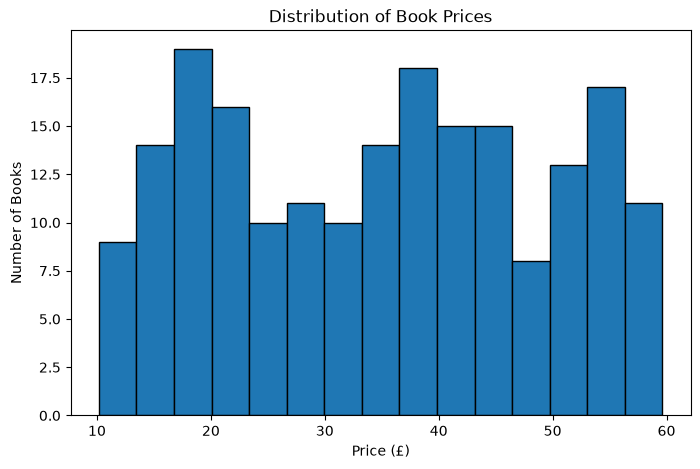

In [98]:
plt.figure(figsize=(8,5))

plt.hist(clean_df["price"], bins=15, edgecolor="black")

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.savefig("price_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [100]:
import os

os.path.exists("price_distribution.png")

True

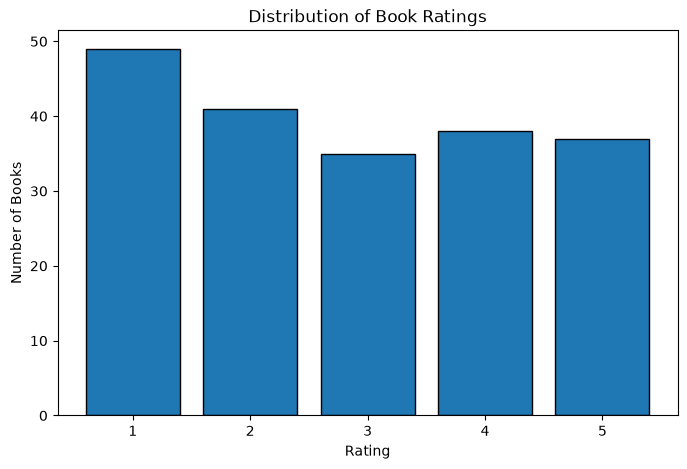

In [102]:
plt.figure(figsize=(8,5))

rating_counts = clean_df["rating"].value_counts().sort_index()

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    edgecolor="black"
)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.savefig("rating_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

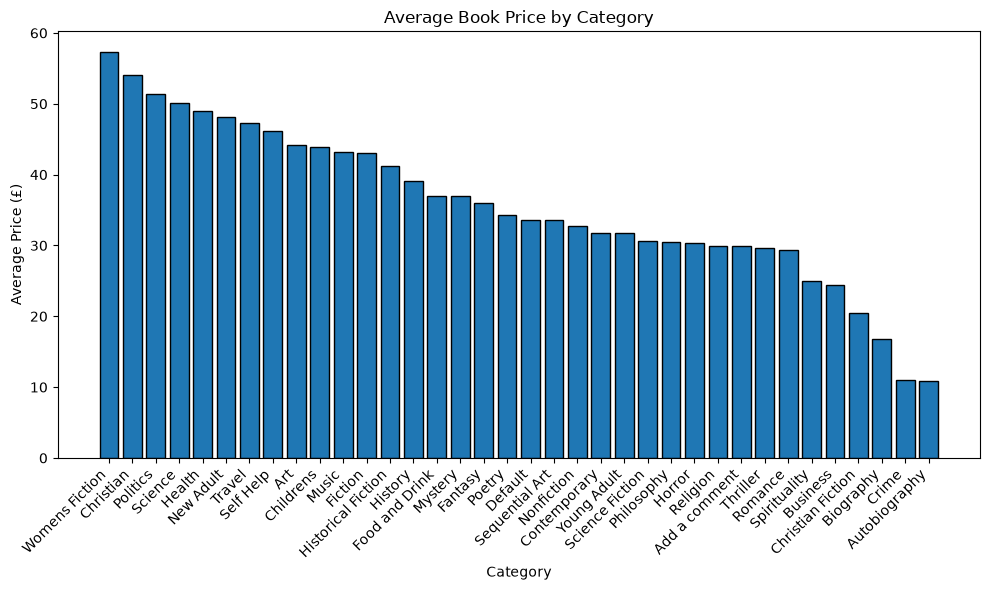

In [103]:
avg_price = (
    clean_df.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    avg_price.index,
    avg_price.values,
    edgecolor="black"
)

plt.title("Average Book Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("average_price_by_category.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

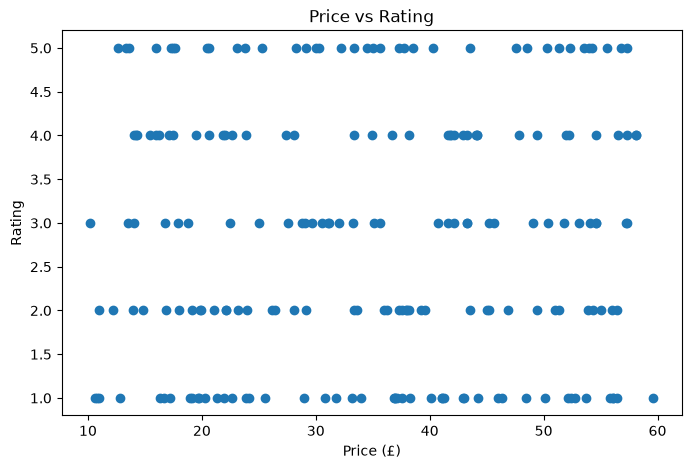

In [104]:
plt.figure(figsize=(8,5))

plt.scatter(
    clean_df["price"],
    clean_df["rating"]
)

plt.title("Price vs Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.savefig("price_vs_rating.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

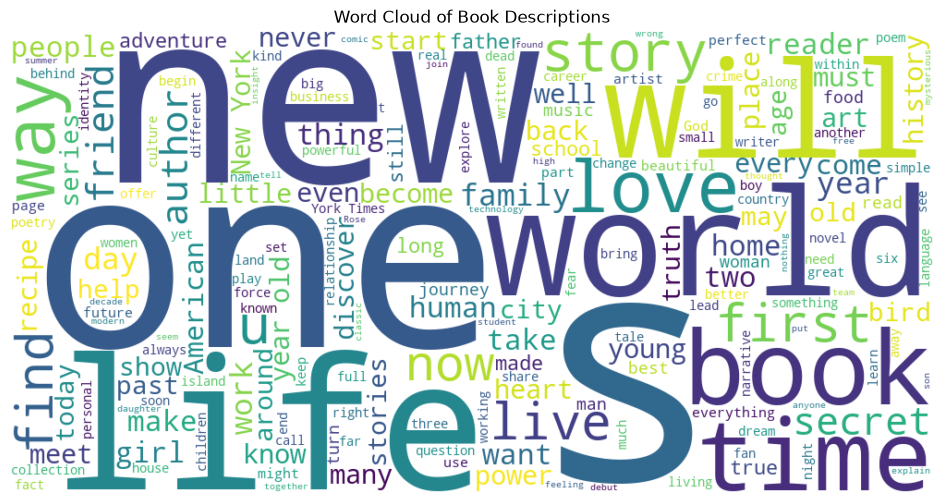

In [106]:
from wordcloud import WordCloud

text = " ".join(clean_df["description"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")

plt.savefig("wordcloud.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [107]:
print("Dataset Shape:", clean_df.shape)

print("\nAverage Price: £", round(clean_df["price"].mean(), 2))
print("Median Price: £", round(clean_df["price"].median(), 2))
print("Minimum Price: £", clean_df["price"].min())
print("Maximum Price: £", clean_df["price"].max())

print("\nAverage Rating:", round(clean_df["rating"].mean(), 2))
print("Highest Rating:", clean_df["rating"].max())

Dataset Shape: (200, 15)

Average Price: £ 34.8
Median Price: £ 35.64
Minimum Price: £ 10.16
Maximum Price: £ 59.64

Average Rating: 2.86
Highest Rating: 5


In [108]:
clean_df["rating"].value_counts().sort_index()

rating
1    49
2    41
3    35
4    38
5    37
Name: count, dtype: int64

In [109]:
 clean_df["category"].value_counts()

category
Default               31
Sequential Art        23
Nonfiction            20
Young Adult           10
Fantasy               10
Poetry                 9
Romance                9
Food and Drink         9
Fiction                9
Add a comment          7
Science Fiction        5
History                5
Mystery                5
Childrens              5
Historical Fiction     5
Business               4
Music                  3
Thriller               3
Philosophy             3
New Adult              3
Travel                 2
Spirituality           2
Horror                 2
Self Help              2
Religion               2
Science                2
Politics               1
Art                    1
Contemporary           1
Health                 1
Christian              1
Crime                  1
Christian Fiction      1
Womens Fiction         1
Biography              1
Autobiography          1
Name: count, dtype: int64

In [110]:
clean_df.groupby("category")["price"].mean().sort_values(ascending=False)

category
Womens Fiction        57.360000
Christian             54.000000
Politics              51.330000
Science               50.160000
Health                49.050000
New Adult             48.070000
Travel                47.300000
Self Help             46.190000
Art                   44.180000
Childrens             43.842000
Music                 43.196667
Fiction               43.048889
Historical Fiction    41.232000
History               39.080000
Food and Drink        36.975556
Mystery               36.938000
Fantasy               35.962000
Poetry                34.323333
Default               33.561935
Sequential Art        33.524783
Nonfiction            32.690000
Contemporary          31.770000
Young Adult           31.751000
Science Fiction       30.666000
Philosophy            30.496667
Horror                30.305000
Religion              29.920000
Add a comment         29.861429
Thriller              29.626667
Romance               29.295556
Spirituality          24.950000

In [111]:
clean_df["recommended"].value_counts()

recommended
False    162
True      38
Name: count, dtype: int64

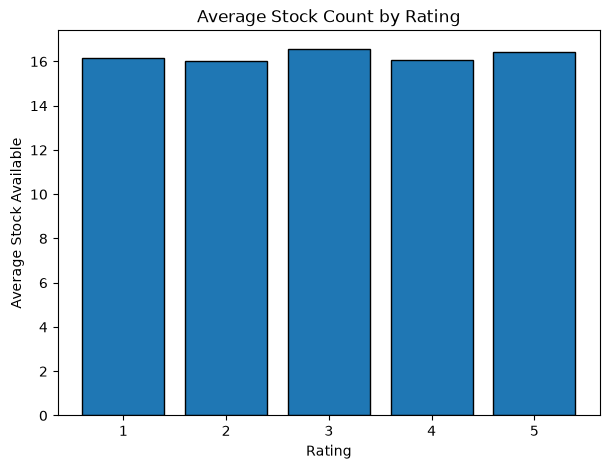

In [118]:
stock_by_rating = clean_df.groupby("rating")["stock_count"].mean()

plt.figure(figsize=(7,5))

plt.bar(
    stock_by_rating.index.astype(str),
    stock_by_rating.values,
    edgecolor="black"
)

plt.title("Average Stock Count by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Stock Available")

plt.show()

In [120]:
We were presented with a site whose data scapping has to be done. The Objective was build a complete data pipeline by scraping book information using 
Python and Scrapy, cleaning and transforming the collected data, creating visualizations, and reporting meaningful data-driven insights.
After the data scrapping and data visualization the following observation was produced on the data set:-
The dataset contained 200 books collected from multiple pages. Though preprocessing the duplicate records and missing values were removed and price 
and stock information were converted into numerical values.
    
1. The average stock count remains almost constant across all rating levels. Books with ratings from 1 to 5 have very similar inventory levels. No 
significant relationship between a book's rating and the number of copies available in stock.

2. Categories such as Christian Fiction, Business, and Spirituality have noticeably lower average prices.
Book prices vary considerably across categories.
        
3. Ratings from 1 to 5 are distributed across almost every price range. High-priced books receive both low and high ratings. Low-priced books also 
receive both low and high ratings. There is no clear correlation between book price and customer rating.

SyntaxError: unterminated string literal (detected at line 9) (3432527467.py, line 9)